# ForecastLLM - Week 7 Day 2: Prompt Dataset and Base Model

This notebook adapts the original Week 7 Day 2 data-prep flow from pricing to forecasting.

## What changed vs. original

- Replaced product items with time-series forecasting rows from Week 6-style features.
- Built prompt/completion datasets for train/validation/test splits.
- Kept token-length analysis, truncation cutoff, and optional Hugging Face push.

## Order Of Play

DAY 1: QLoRA setup
DAY 2: Prompt data and base model (this notebook)
DAY 3: Train part 1
DAY 4: Train part 2
DAY 5: Eval

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import Dataset, DatasetDict
from huggingface_hub import login
from transformers import AutoTokenizer
from dotenv import load_dotenv

from week6.data_loader import load_sample_series

In [3]:
load_dotenv()

LITE_MODE = os.getenv("LITE_MODE", "0").lower() in {"1", "true", "yes"}

BASE_MODEL = os.getenv("BASE_MODEL", "TinyLlama/TinyLlama-1.1B-Chat-v1.0")
HF_TOKEN = os.getenv("HF_TOKEN", "")
HF_USERNAME = os.getenv("HF_USERNAME", "")

print(f"LITE_MODE={LITE_MODE}")
print(f"BASE_MODEL={BASE_MODEL}")
print(f"FORECAST_DATA_PATH={os.getenv('FORECAST_DATA_PATH')}")

if HF_TOKEN:
    login(HF_TOKEN, add_to_git_credential=True)
    print("Hugging Face authentication configured from HF_TOKEN.")
else:
    print("HF_TOKEN not set; continuing without hub authentication.")

LITE_MODE=False
BASE_MODEL=TinyLlama/TinyLlama-1.1B-Chat-v1.0
HF_TOKEN not set; continuing without hub authentication.


In [4]:
def make_synthetic_series(periods=300):
    dates = pd.date_range("2024-01-01", periods=periods, freq="D")
    trend = np.linspace(80, 120, periods)
    weekly = 6 * np.sin(np.arange(periods) * 2 * np.pi / 7)
    noise = np.random.default_rng(42).normal(scale=1.2, size=periods)
    return pd.DataFrame({"timestamp": dates, "value": trend + weekly + noise})

loaded = None
try:
    loaded = load_sample_series()
except (FileNotFoundError, ValueError, TypeError, OSError) as e:
    print(f"Loader failed ({e}); using fallback")

if isinstance(loaded, pd.Series):
    normalized_df = loaded.rename("value").to_frame().reset_index()
    if normalized_df.shape[1] == 2:
        normalized_df.columns = ["timestamp", "value"]
elif isinstance(loaded, pd.DataFrame):
    normalized_df = loaded.copy()
else:
    normalized_df = make_synthetic_series()

if "value" not in normalized_df.columns:
    numeric_cols = normalized_df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        normalized_df = normalized_df.rename(columns={numeric_cols[0]: "value"})
    else:
        normalized_df = make_synthetic_series()

if "timestamp" not in normalized_df.columns:
    normalized_df = normalized_df.reset_index().rename(columns={normalized_df.index.name or "index": "timestamp"})

ts_df = normalized_df[["timestamp", "value"]].copy()
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["value"]).sort_values("timestamp").reset_index(drop=True)

if ts_df["timestamp"].isna().all() or len(ts_df) < 90:
    ts_df = make_synthetic_series()

print(f"Loaded {len(ts_df):,} rows")
print(ts_df.head())

Loaded 300 rows
   timestamp      value
0 2024-01-01  80.365660
1 2024-01-02  83.576787
2 2024-01-03  87.017667
3 2024-01-04  84.133318
4 2024-01-05  75.590572


In [5]:
# Build supervised lag/calendar features (hourly protocol)
supervised_df = ts_df.copy()
supervised_df["lag_1"] = supervised_df["value"].shift(1)
supervised_df["lag_24"] = supervised_df["value"].shift(24)
supervised_df["lag_168"] = supervised_df["value"].shift(168)
supervised_df["hour_of_day"] = supervised_df["timestamp"].dt.hour
supervised_df["day_of_week"] = supervised_df["timestamp"].dt.dayofweek
supervised_df = supervised_df.dropna().reset_index(drop=True)

if LITE_MODE:
    supervised_df = supervised_df.tail(min(len(supervised_df), 160)).reset_index(drop=True)

n = len(supervised_df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = supervised_df.iloc[:train_end].copy()
val_df = supervised_df.iloc[train_end:val_end].copy()
test_df = supervised_df.iloc[val_end:].copy()

print(f"Train={len(train_df):,}, Val={len(val_df):,}, Test={len(test_df):,}")
print(train_df.head())

Train=205, Val=44, Test=44
   timestamp      value      lag_1      lag_2      lag_3      lag_7  \
0 2024-01-08  80.556964  76.265095  73.256713  75.590572  80.365660   
1 2024-01-09  85.741062  80.556964  76.265095  73.256713  83.576787   
2 2024-01-10  86.029928  85.741062  80.556964  76.265095  87.017667   
3 2024-01-11  84.996373  86.029928  85.741062  80.556964  84.133318   
4 2024-01-12  79.801620  84.996373  86.029928  85.741062  75.590572   

   day_of_week  month  
0            0      1  
1            1      1  
2            2      1  
3            3      1  
4            4      1  


In [6]:
from_pretrained = getattr(AutoTokenizer, "from_pretrained", None)
if from_pretrained is None:
    raise RuntimeError("AutoTokenizer.from_pretrained is unavailable")

tokenizer = from_pretrained(BASE_MODEL)
if tokenizer is None:
    raise RuntimeError(f"Tokenizer load failed for {BASE_MODEL}")

if getattr(tokenizer, "pad_token", None) is None and getattr(tokenizer, "eos_token", None) is not None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded:", BASE_MODEL)

Tokenizer loaded: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [7]:
def feature_summary(row):
    return (
        f"timestamp={row['timestamp']}, lag_1={row['lag_1']:.3f}, lag_24={row['lag_24']:.3f}, "
        f"lag_168={row['lag_168']:.3f}, hour_of_day={int(row['hour_of_day'])}, day_of_week={int(row['day_of_week'])}"
    )

all_rows = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)
summaries = [feature_summary(row) for _, row in all_rows.iterrows()]

tokenizer_call = getattr(tokenizer, "__call__", None)
if tokenizer_call is None:
    raise RuntimeError("Tokenizer is not callable")

token_counts = [len(tokenizer_call(text, add_special_tokens=False)["input_ids"]) for text in tqdm(summaries)]

print(f"Summary token stats: avg={np.mean(token_counts):.1f}, p95={np.percentile(token_counts, 95):.1f}, max={np.max(token_counts)}")

100%|██████████| 293/293 [00:00<00:00, 33826.89it/s]

Summary token stats: avg=70.0, p95=73.0, max=73


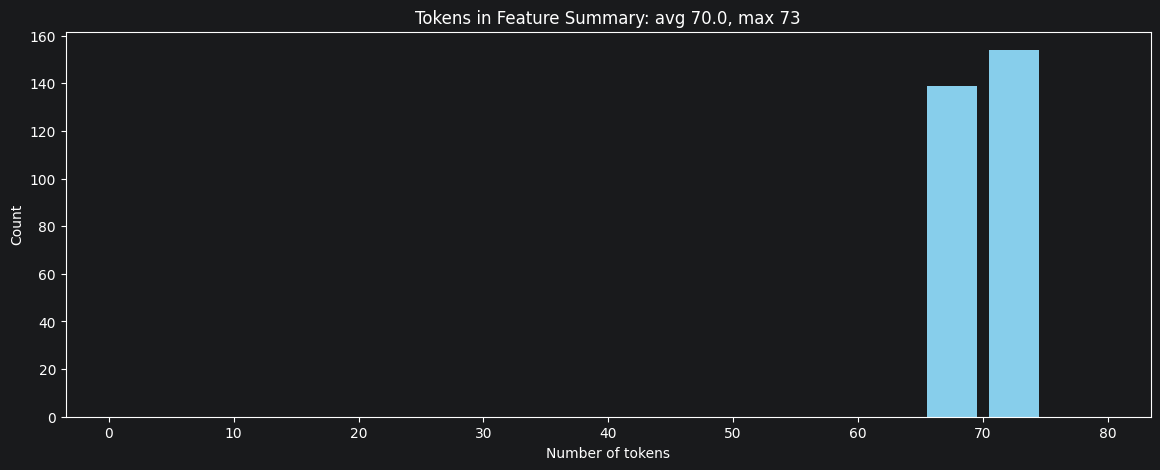

In [8]:
if not token_counts:
    raise RuntimeError("token_counts is empty")

plt.figure(figsize=(14, 5))
plt.title(f"Tokens in Feature Summary: avg {np.mean(token_counts):,.1f}, max {np.max(token_counts):,}")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.hist(token_counts, rwidth=0.8, color="skyblue", bins=range(0, max(token_counts) + 10, 5))
plt.show()

In [9]:
CUTOFF = int(np.percentile(token_counts, 95))
truncated = sum(count > CUTOFF for count in token_counts)
print(f"CUTOFF={CUTOFF}. Truncating {truncated:,}/{len(token_counts):,} rows ({truncated/len(token_counts):.1%}).")

CUTOFF=73. Truncating 0/293 rows (0.0%).


In [10]:
def truncate_to_tokens(text, tok, cutoff):
    tok_call = getattr(tok, "__call__", None)
    if tok_call is None:
        raise RuntimeError("Tokenizer is not callable")

    ids = tok_call(text, add_special_tokens=False)["input_ids"]
    if len(ids) <= cutoff:
        return text

    decode_fn = getattr(tok, "decode", None)
    if decode_fn is None:
        raise RuntimeError("Tokenizer decode is unavailable")

    trimmed = ids[:cutoff]
    return decode_fn(trimmed, skip_special_tokens=True)

def build_prompt_from_row(row, tok, cutoff):
    summary = truncate_to_tokens(feature_summary(row), tok, cutoff)
    return (
        "You are a forecasting assistant.\n"
        "Given the following recent-series context, predict the next hourly value.\n"
        f"{summary}\n"
        "Return only a numeric forecast."
    )

def build_completion_from_row(row):
    return f"{row['value']:.3f}"

def make_records(df, include_completion):
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        prompt = build_prompt_from_row(row, tokenizer, CUTOFF)
        completion = build_completion_from_row(row)
        record = {"prompt": prompt, "completion": completion}
        if include_completion:
            record["text"] = f"{prompt}\n{completion}"
        else:
            record["text"] = prompt
        records.append(record)
    return records

In [11]:
train_records = make_records(train_df, include_completion=True)
val_records = make_records(val_df, include_completion=True)
test_records = make_records(test_df, include_completion=False)

print(
    f"Prepared prompt records: train={len(train_records):,}, val={len(val_records):,}, test={len(test_records):,}"
)

100%|██████████| 44/44 [00:00<00:00, 20286.84it/s]

Prepared prompt records: train=205, val=44, test=44


In [12]:
print("PROMPT:\n")
print(test_records[0]["prompt"])
print("\nCOMPLETION (held out target):")
print(test_records[0]["completion"])

PROMPT:

You are a forecasting assistant.
Given the following recent-series context, predict the next daily value.
timestamp=2024-09-13, lag_1=117.650, lag_2=119.535, lag_3=117.353, lag_7=109.302, day_of_week=4, month=9
Return only a numeric forecast.

COMPLETION (held out target):
112.166


100%|██████████| 293/293 [00:00<00:00, 21704.89it/s]


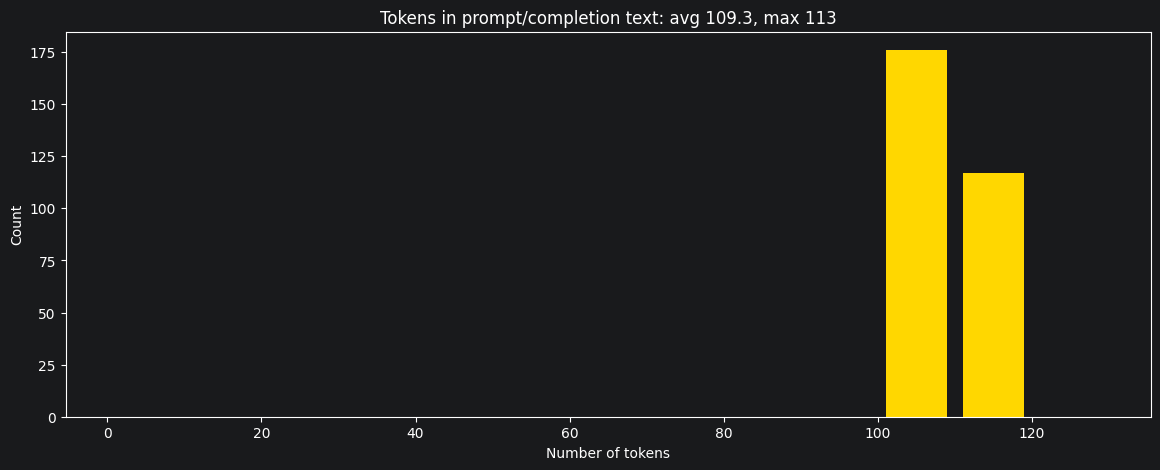

In [13]:
tokenizer_call = getattr(tokenizer, "__call__", None)
if tokenizer_call is None:
    raise RuntimeError("Tokenizer is not callable")

prompt_token_counts = [
    len(tokenizer_call(record["text"], add_special_tokens=False)["input_ids"])
    for record in tqdm(train_records + val_records + test_records)
]

if not prompt_token_counts:
    raise RuntimeError("prompt_token_counts is empty")

plt.figure(figsize=(14, 5))
plt.title(f"Tokens in prompt/completion text: avg {np.mean(prompt_token_counts):,.1f}, max {np.max(prompt_token_counts):,}")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.hist(prompt_token_counts, rwidth=0.8, color="gold", bins=range(0, max(prompt_token_counts) + 20, 10))
plt.show()

In [14]:
dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(pd.DataFrame(train_records), preserve_index=False),
    "validation": Dataset.from_pandas(pd.DataFrame(val_records), preserve_index=False),
    "test": Dataset.from_pandas(pd.DataFrame(test_records), preserve_index=False),
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['prompt', 'completion', 'text'],
        num_rows: 205
    })
    validation: Dataset({
        features: ['prompt', 'completion', 'text'],
        num_rows: 44
    })
    test: Dataset({
        features: ['prompt', 'completion', 'text'],
        num_rows: 44
    })
})

In [15]:
if HF_USERNAME:
    dataset_name = f"{HF_USERNAME}/forecast_prompts_lite" if LITE_MODE else f"{HF_USERNAME}/forecast_prompts_full"
    if HF_TOKEN:
        dataset_dict.push_to_hub(dataset_name)
        print(f"Uploaded dataset to: https://huggingface.co/datasets/{dataset_name}")
    else:
        print("HF_USERNAME set but HF_TOKEN missing; skipping push_to_hub.")
        print("Would upload dataset:", dataset_name)
else:
    print("HF_USERNAME not set; skipping push_to_hub.")

HF_USERNAME not set; skipping push_to_hub.


## Day 2 Wrap-up

- Created forecasting prompt/completion datasets for train/validation/test.
- Measured token lengths, selected a truncation cutoff, and regenerated prompts accordingly.
- Prepared a `DatasetDict` suitable for Day 3/4 fine-tuning.
- Optional Hugging Face upload is supported via `HF_USERNAME` + `HF_TOKEN`.